<a href="https://colab.research.google.com/github/shailshree23/ML2_Lab/blob/main/Bagging%26Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully!")

print("\nDataset shape:")
print(X.shape)

print("\nFeature names:")
print(data.feature_names)

print("\nTarget classes:")
print(data.target_names)

print("\nFirst 5 rows:")
print(X[:5])

print("\nFirst 5 target values:")
print(y[:5])

Dataset loaded successfully!

Dataset shape:
(569, 30)

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target classes:
['malignant' 'benign']

First 5 rows:
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e

In [3]:
df = pd.DataFrame(
    X,
    columns=data.feature_names
)

df["target"] = y

print("First 5 rows:")
display(df.head())

print("\nDataset information:")
print(df.info())

print("\nClass distribution:")
print(df["target"].value_counts())

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

In [4]:
print("Missing values in each column:")

print(
    df.isnull().sum()
)

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Total missing values: 0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

print("\nTraining labels:")
print(y_train.shape)

print("\nTesting labels:")
print(y_test.shape)

Training data shape:
(455, 30)

Testing data shape:
(114, 30)

Training labels:
(455,)

Testing labels:
(114,)


In [6]:
base_tree = DecisionTreeClassifier(
    random_state=42
)

print("Base Decision Tree created.")

Base Decision Tree created.


In [7]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=10,
    random_state=42
)

# Train the model
bagging_model.fit(
    X_train,
    y_train
)

print("Bagging model trained successfully!")

Bagging model trained successfully!


In [8]:
y_pred_bagging = bagging_model.predict(
    X_test
)

print("Bagging predictions:")
print(y_pred_bagging)

Bagging predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [9]:
bagging_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

bagging_precision = precision_score(
    y_test,
    y_pred_bagging
)

bagging_recall = recall_score(
    y_test,
    y_pred_bagging
)

bagging_f1 = f1_score(
    y_test,
    y_pred_bagging
)

print("=" * 50)
print("BAGGING PERFORMANCE")
print("=" * 50)

print(
    "Accuracy  :", round(bagging_accuracy, 4)
)

print(
    "Precision :", round(bagging_precision, 4)
)

print(
    "Recall    :", round(bagging_recall, 4)
)

print(
    "F1 Score  :", round(bagging_f1, 4)
)

BAGGING PERFORMANCE
Accuracy  : 0.9298
Precision : 0.9444
Recall    : 0.9444
F1 Score  : 0.9444


In [10]:
print("Bagging Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_bagging,
        target_names=data.target_names
    )
)

Bagging Classification Report:

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



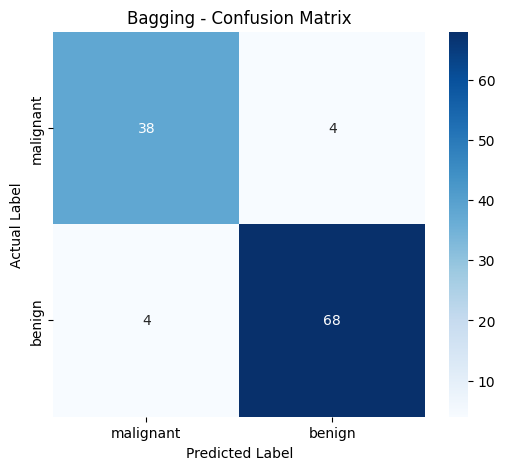

In [11]:
cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm_bagging,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Bagging - Confusion Matrix")

plt.show()

In [12]:
boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Train the model
boosting_model.fit(
    X_train,
    y_train
)

print("AdaBoost model trained successfully!")

AdaBoost model trained successfully!


In [13]:
y_pred_boosting = boosting_model.predict(
    X_test
)

print("Boosting predictions:")
print(y_pred_boosting)

Boosting predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [14]:
boosting_accuracy = accuracy_score(
    y_test,
    y_pred_boosting
)

boosting_precision = precision_score(
    y_test,
    y_pred_boosting
)

boosting_recall = recall_score(
    y_test,
    y_pred_boosting
)

boosting_f1 = f1_score(
    y_test,
    y_pred_boosting
)

print("=" * 50)
print("BOOSTING PERFORMANCE")
print("=" * 50)

print(
    "Accuracy  :", round(boosting_accuracy, 4)
)

print(
    "Precision :", round(boosting_precision, 4)
)

print(
    "Recall    :", round(boosting_recall, 4)
)

print(
    "F1 Score  :", round(boosting_f1, 4)
)

BOOSTING PERFORMANCE
Accuracy  : 0.9561
Precision : 0.9467
Recall    : 0.9861
F1 Score  : 0.966


In [15]:
print("Boosting Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_boosting,
        target_names=data.target_names
    )
)

Boosting Classification Report:

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



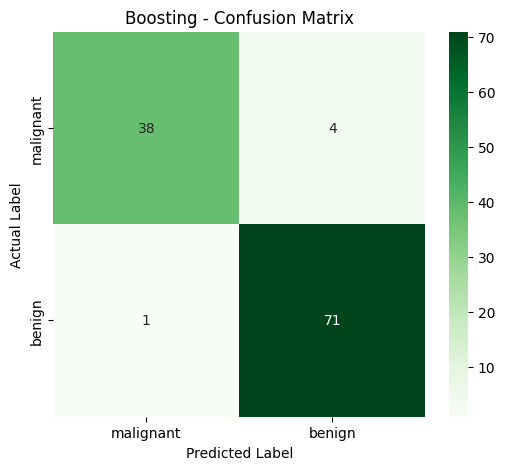

In [16]:
cm_boosting = confusion_matrix(
    y_test,
    y_pred_boosting
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm_boosting,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Boosting - Confusion Matrix")

plt.show()

In [17]:
comparison = pd.DataFrame({

    "Model": [
        "Bagging",
        "Boosting"
    ],

    "Accuracy": [
        bagging_accuracy,
        boosting_accuracy
    ],

    "Precision": [
        bagging_precision,
        boosting_precision
    ],

    "Recall": [
        bagging_recall,
        boosting_recall
    ],

    "F1 Score": [
        bagging_f1,
        boosting_f1
    ]
})

print("MODEL PERFORMANCE COMPARISON")

display(
    comparison.round(4)
)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.9298,0.9444,0.9444,0.9444
1,Boosting,0.9561,0.9467,0.9861,0.9660


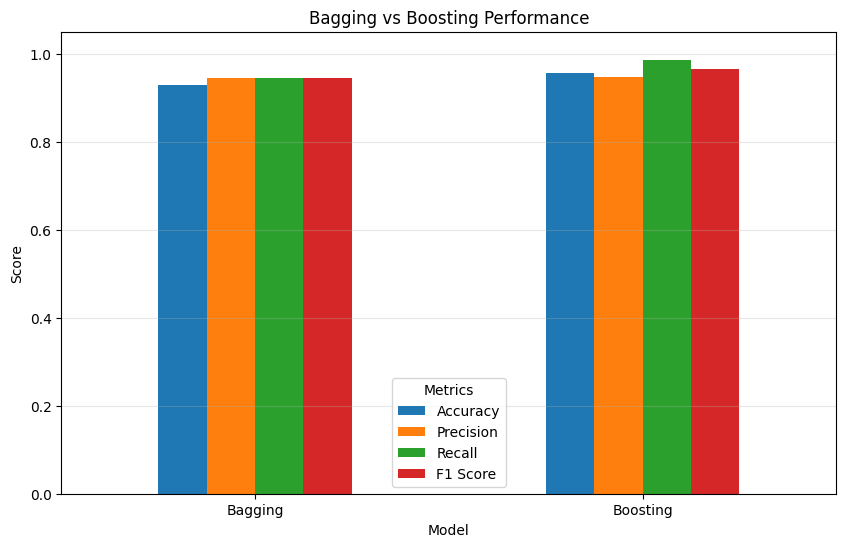

In [18]:
comparison_plot = comparison.set_index(
    "Model"
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Bagging vs Boosting Performance"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metrics"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

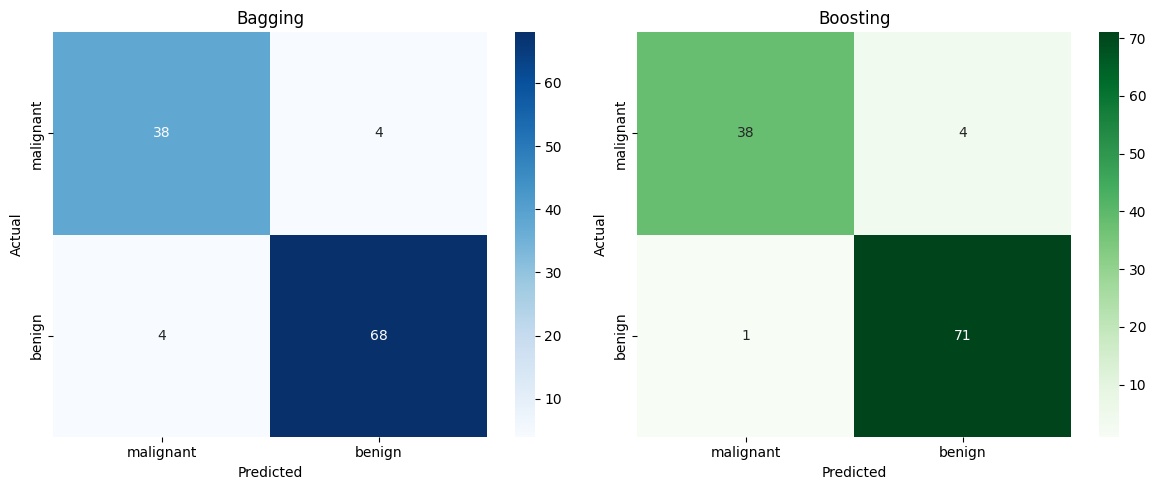

In [19]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Bagging
sns.heatmap(
    cm_bagging,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names,
    ax=axes[0]
)

axes[0].set_title(
    "Bagging"
)

axes[0].set_xlabel(
    "Predicted"
)

axes[0].set_ylabel(
    "Actual"
)


# Boosting
sns.heatmap(
    cm_boosting,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=data.target_names,
    yticklabels=data.target_names,
    ax=axes[1]
)

axes[1].set_title(
    "Boosting"
)

axes[1].set_xlabel(
    "Predicted"
)

axes[1].set_ylabel(
    "Actual"
)

plt.tight_layout()

plt.show()

In [20]:
print("=" * 65)
print("FINAL PERFORMANCE REPORT".center(65))
print("=" * 65)

print("\nDataset:")
print("Breast Cancer Wisconsin Dataset")

print("\nNumber of samples:", len(X))
print("Number of features:", X.shape[1])

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\n" + "-" * 65)

print("BAGGING")
print("-" * 65)

print("Accuracy :", round(bagging_accuracy, 4))
print("Precision:", round(bagging_precision, 4))
print("Recall   :", round(bagging_recall, 4))
print("F1 Score :", round(bagging_f1, 4))

print("\n" + "-" * 65)

print("BOOSTING")
print("-" * 65)

print("Accuracy :", round(boosting_accuracy, 4))
print("Precision:", round(boosting_precision, 4))
print("Recall   :", round(boosting_recall, 4))
print("F1 Score :", round(boosting_f1, 4))

print("\n" + "=" * 65)
print("COMPARISON")
print("=" * 65)

display(
    comparison.round(4)
)

                     FINAL PERFORMANCE REPORT                    

Dataset:
Breast Cancer Wisconsin Dataset

Number of samples: 569
Number of features: 30

Training samples: 455
Testing samples: 114

-----------------------------------------------------------------
BAGGING
-----------------------------------------------------------------
Accuracy : 0.9298
Precision: 0.9444
Recall   : 0.9444
F1 Score : 0.9444

-----------------------------------------------------------------
BOOSTING
-----------------------------------------------------------------
Accuracy : 0.9561
Precision: 0.9467
Recall   : 0.9861
F1 Score : 0.966

COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.9298,0.9444,0.9444,0.9444
1,Boosting,0.9561,0.9467,0.9861,0.9660
